In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Carrega o dataset
df = pd.read_csv("../data/ai4i2020.csv")

# Primeiros registros
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
print("Shape do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEstatísticas descritivas:")
df.describe()

Shape do dataset: (10000, 14)

Tipos de dados:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Valores nulos:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Estatísticas 

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Distribuição de falhas:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentual de falhas: 3.39%


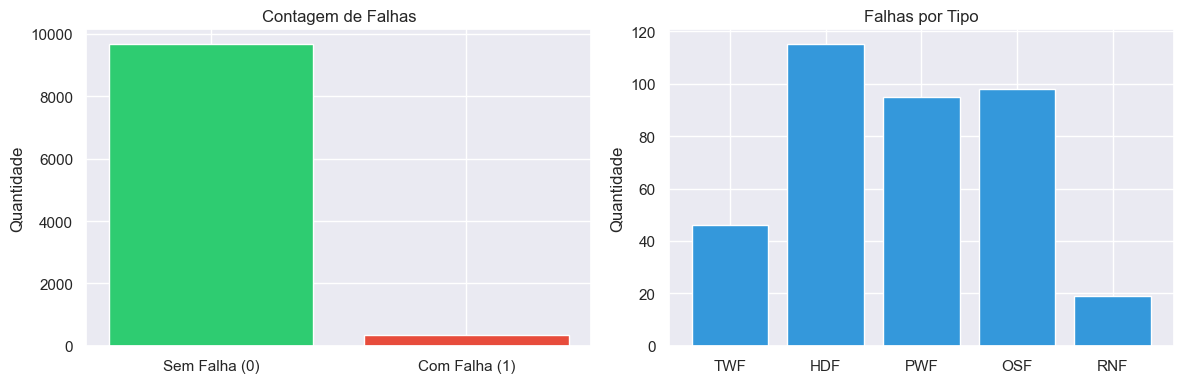

In [3]:
# Distribuição da variável target
falhas = df["Machine failure"].value_counts()
print("Distribuição de falhas:")
print(falhas)
print(f"\nPercentual de falhas: {falhas[1] / len(df) * 100:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de contagem
axes[0].bar(["Sem Falha (0)", "Com Falha (1)"], 
            [falhas[0], falhas[1]], 
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Contagem de Falhas")
axes[0].set_ylabel("Quantidade")

# Tipos de falha
tipos_falha = df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()
axes[1].bar(tipos_falha.index, tipos_falha.values, color="#3498db")
axes[1].set_title("Falhas por Tipo")
axes[1].set_ylabel("Quantidade")

plt.tight_layout()
plt.show()

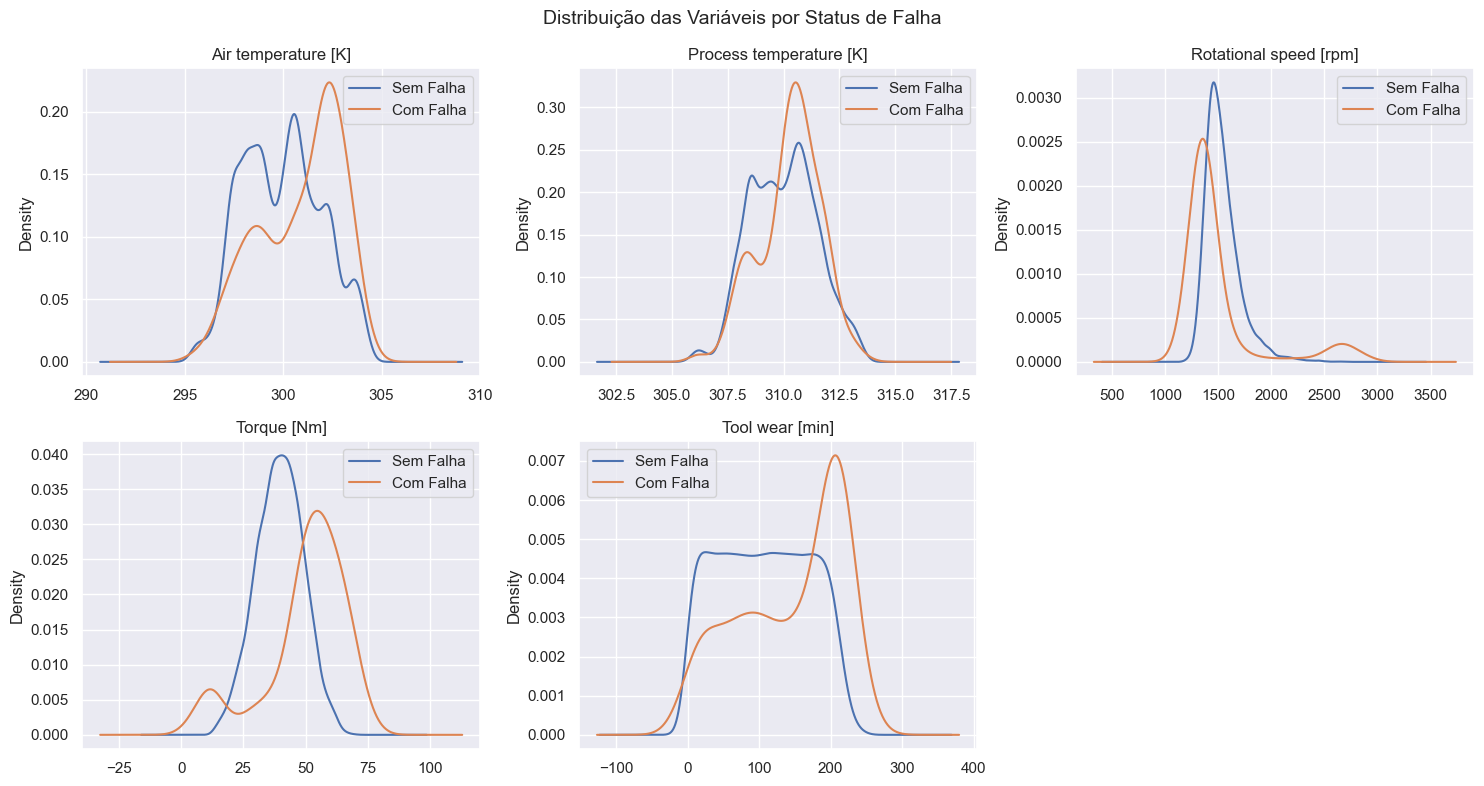

In [4]:
# Comparação das variáveis numéricas entre falha e sem falha
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.groupby("Machine failure")[feature].plot(
        kind="kde",
        ax=axes[i],
        legend=True,
        title=feature
    )
    axes[i].legend(["Sem Falha", "Com Falha"])

axes[5].set_visible(False)
plt.suptitle("Distribuição das Variáveis por Status de Falha", fontsize=14)
plt.tight_layout()
plt.show()

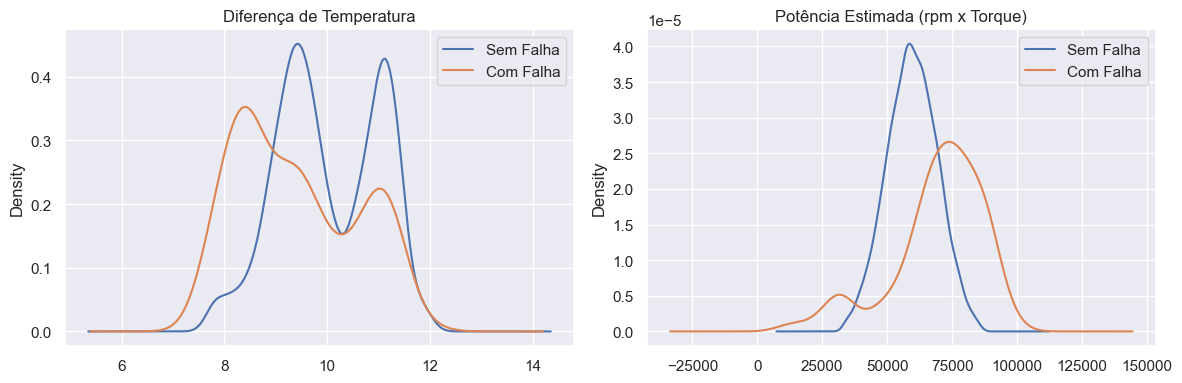

In [5]:
# Feature de engenharia: diferença de temperatura
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# Feature de engenharia: potência estimada
df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]

# Verificar se essas features separam melhor as classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby("Machine failure")["temp_diff"].plot(
    kind="kde", ax=axes[0], legend=True, title="Diferença de Temperatura"
)
axes[0].legend(["Sem Falha", "Com Falha"])

df.groupby("Machine failure")["power"].plot(
    kind="kde", ax=axes[1], legend=True, title="Potência Estimada (rpm x Torque)"
)
axes[1].legend(["Sem Falha", "Com Falha"])

plt.tight_layout()
plt.show()

In [6]:
print("=== RESUMO DA ANÁLISE EXPLORATÓRIA ===")
print(f"\nTotal de registros: {len(df)}")
print(f"Taxa de falha: {df['Machine failure'].mean() * 100:.2f}%")
print(f"\nModo de falha mais comum: HDF (Heat Dissipation Failure)")
print(f"\nVariáveis com maior poder preditivo:")
print("  - Torque [Nm]")
print("  - Tool wear [min]")
print("  - Air temperature [K]")
print(f"\nFeatures de engenharia criadas:")
print("  - temp_diff: diferença entre temperatura do processo e do ar")
print("  - power: produto entre rotação e torque (potência estimada)")
print("\nDataset desbalanceado: requer uso de Recall e F1-Score na avaliação")

=== RESUMO DA ANÁLISE EXPLORATÓRIA ===

Total de registros: 10000
Taxa de falha: 3.39%

Modo de falha mais comum: HDF (Heat Dissipation Failure)

Variáveis com maior poder preditivo:
  - Torque [Nm]
  - Tool wear [min]
  - Air temperature [K]

Features de engenharia criadas:
  - temp_diff: diferença entre temperatura do processo e do ar
  - power: produto entre rotação e torque (potência estimada)

Dataset desbalanceado: requer uso de Recall e F1-Score na avaliação
